# Clinical v28 집계 보고서

PUBLIC_REPORT.json만 읽어 표와 그림을 재현하는 미실행 템플릿이다. 원자료·개인별 예측·모델을 읽거나 학습·선택·평가를 실행하는 셀은 없다. 실행본은 별도 파일로 보존한다.

In [1]:
import hashlib, json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
path = Path('PUBLIC_REPORT.json')
assert hashlib.sha256(path.read_bytes()).hexdigest() == 'd9f002961a12e16c1ced71f82940be3a051c66ac295237e44de36c43de0bce36', 'Aggregate hash changed'
R = json.loads(path.read_text(encoding='utf-8'))
CELLS = ('binary_Linear', 'binary_MLP', 'binary_EPF', 'binary_EPF_noP', 'binary_EPF_step1', 'joint_Linear', 'joint_MLP', 'joint_EPF', 'joint_EPF_noP', 'joint_EPF_step1')
ARCHS = ('Linear', 'MLP', 'EPF', 'EPF_noP', 'EPF_step1')
DESIGNS = ('binary', 'joint')
assert R['version'] == 'clinical_factorial_v28' and set(R['cells']) == set(CELLS)
pd.set_option('display.max_rows', 60)
pd.set_option('display.max_columns', 15)
display(pd.DataFrame([{'rule': key, 'value': value} for key, value in R['prespecified_rules'].items()]))

,rule,value
0,equivalence_margin,0.005
1,h1_all_five_supported,False
2,h1_rule,All five pointwise PSU 95% lower bounds strict...
3,h2_all_four_supported,False
4,h2_noP_and_step1_supported,True
5,h2_rule,Pointwise PSU 90% interval strictly inside (-0...
6,runbook_architecture_extension_pattern_met,False
7,runbook_claim_pattern_met,False


## 2 × 5 macro AP와 16상태 NLL

AP는 높을수록, NLL은 낮을수록 좋다. 열 이름 Linear는 joint 평균 경로만 뜻한다. heatmap 색 범위는 관측 AP 주변의 좁은 범위이므로 숫자 라벨을 함께 읽는다.

macro_ap


,Linear,MLP,EPF,EPF_noP,EPF_step1
binary,0.364904,0.365099,0.363787,0.363777,0.364212
joint,0.375376,0.378114,0.381397,0.380671,0.380608


joint16_nll


,Linear,MLP,EPF,EPF_noP,EPF_step1
binary,1.388554,1.386931,1.389019,1.389031,1.388051
joint,1.359474,1.365152,1.364834,1.365113,1.364207


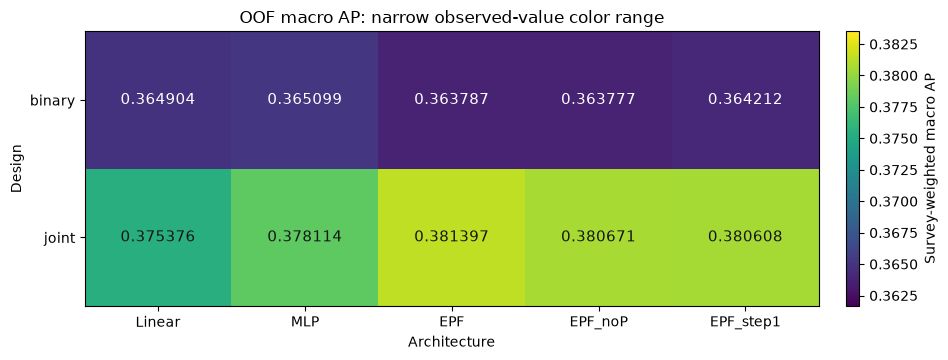

In [2]:
for metric in ('macro_ap', 'joint16_nll'):
    print(metric)
    display(pd.DataFrame([[R['cells'][f'{design}_{arch}'][metric] for arch in ARCHS] for design in DESIGNS], index=DESIGNS, columns=ARCHS))
values = [[R['cells'][f'{design}_{arch}']['macro_ap'] for arch in ('Linear', 'MLP', 'EPF', 'EPF_noP', 'EPF_step1')] for design in ('binary', 'joint')]
lo, hi = min(map(min, values)), max(map(max, values))
pad = max((hi - lo) * .12, .001)
vmin, vmax = max(0., lo - pad), min(1., hi + pad)
fig, ax = plt.subplots(figsize=(10, 3.7))
im = ax.imshow(values, cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
for i, row in enumerate(values):
    for j, value in enumerate(row):
        ax.text(j, i, f'{value:.6f}', ha='center', va='center', fontsize=11,
                color='white' if (value-vmin)/(vmax-vmin) < .52 else '#151515')
ax.set_xticks(range(5), ('Linear', 'MLP', 'EPF', 'EPF_noP', 'EPF_step1')); ax.set_yticks(range(2), ('binary', 'joint'))
ax.set_xlabel('Architecture'); ax.set_ylabel('Design')
ax.set_title('OOF macro AP: narrow observed-value color range')
fig.colorbar(im, ax=ax, label='Survey-weighted macro AP', format='%.4f', pad=.03)
fig.tight_layout()
display(fig); plt.close(fig)

## Flag별 AP와 fold별 AP

In [3]:
display(pd.DataFrame([{'cell': name, **dict(zip(R['flags'], R['cells'][name]['per_flag_ap']))} for name in CELLS]))
display(pd.DataFrame([{'cell': name, **{f'fold{i+1}': value for i, value in enumerate(R['cells'][name]['fold_macro_ap'])}} for name in CELLS]))

,cell,elevated_glucose,elevated_bp,elevated_tg,low_hdl
0,binary_Linear,0.369291,0.274778,0.440659,0.374889
1,binary_MLP,0.368568,0.273949,0.441484,0.376397
2,binary_EPF,0.368230,0.274522,0.437698,0.374700
3,binary_EPF_noP,0.368295,0.274425,0.437659,0.374730
4,binary_EPF_step1,0.368023,0.275232,0.437667,0.375924
5,joint_Linear,0.378455,0.283744,0.456604,0.382702
6,joint_MLP,0.381870,0.284281,0.458722,0.387583
7,joint_EPF,0.385222,0.288002,0.463364,0.388999
8,joint_EPF_noP,0.380947,0.286890,0.464769,0.390079
9,joint_EPF_step1,0.380929,0.284394,0.467485,0.389624


,cell,fold1,fold2,fold3,fold4,fold5
0,binary_Linear,0.387081,0.374945,0.347218,0.370144,0.412059
1,binary_MLP,0.387723,0.375597,0.347141,0.369816,0.410935
2,binary_EPF,0.387904,0.370103,0.347387,0.369393,0.412582
3,binary_EPF_noP,0.388237,0.370041,0.347392,0.369435,0.412581
4,binary_EPF_step1,0.387087,0.370941,0.347289,0.369644,0.413606
5,joint_Linear,0.407111,0.399494,0.347792,0.374686,0.413075
6,joint_MLP,0.411573,0.396608,0.356592,0.373273,0.416910
7,joint_EPF,0.410150,0.392860,0.366268,0.387941,0.417180
8,joint_EPF_noP,0.408423,0.396405,0.360458,0.385695,0.416828
9,joint_EPF_step1,0.408241,0.398534,0.363555,0.381480,0.417424


## H1: 다섯 joint − binary 대조

각 pointwise PSU 95% 하한 > 0이면 충족한다. joint는 감독 신호·손실·앵커·헤드를 함께 바꾼 설계 묶음이다.

,contrast,estimate,fold_diff,hypothesis,psu_ci90,psu_ci95,supported
0,joint_Linear-binary_Linear,0.010472,"[0.020030148948096238, 0.024549586101857257, 0...",H1 design effect > 0,"[0.0016499799581181308, 0.018478436501002345]","[-0.00013625977893164936, 0.019695479897497342]",False
1,joint_MLP-binary_MLP,0.013015,"[0.023849490367637838, 0.021010664966106984, 0...",H1 design effect > 0,"[0.0048775608034834165, 0.020267509164934767]","[0.0030107378197199454, 0.02129534318338953]",True
2,joint_EPF-binary_EPF,0.017609,"[0.022246647145230725, 0.022757360835446216, 0...",H1 design effect > 0,"[0.009744967782399819, 0.02533249031696402]","[0.008461944517990466, 0.02664737078484489]",True
3,joint_EPF_noP-binary_EPF_noP,0.016894,"[0.02018605120384248, 0.026364111117634703, 0....",H1 design effect > 0,"[0.009390612749210204, 0.024311361377253426]","[0.00759350195012679, 0.025582951219863863]",True
4,joint_EPF_step1-binary_EPF_step1,0.016396,"[0.021154375017719662, 0.02759368934701706, 0....",H1 design effect > 0,"[0.008582109969303076, 0.02395609489629537]","[0.007244071949223706, 0.025481105098598834]",True


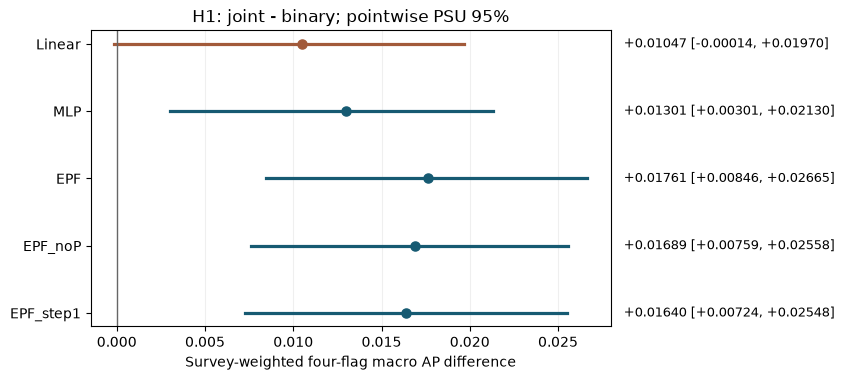

In [4]:
display(pd.DataFrame([{'contrast': name, **R['contrasts'][name]} for name in ('joint_Linear-binary_Linear', 'joint_MLP-binary_MLP', 'joint_EPF-binary_EPF', 'joint_EPF_noP-binary_EPF_noP', 'joint_EPF_step1-binary_EPF_step1')]))
rows = [R['contrasts'][name] for name in ('joint_Linear-binary_Linear', 'joint_MLP-binary_MLP', 'joint_EPF-binary_EPF', 'joint_EPF_noP-binary_EPF_noP', 'joint_EPF_step1-binary_EPF_step1')]
fig, ax = plt.subplots(figsize=(10, 4.7))
if 'h1_ci95' == 'h2_ci90':
    margin = R['prespecified_rules']['equivalence_margin']
    ax.axvspan(-margin, margin, color='#dcebdc', alpha=.6, label='Equivalence margin +/-0.005')
    ax.axvline(-margin, color='#579f67', ls='--', lw=1.2)
    ax.axvline(margin, color='#579f67', ls='--', lw=1.2)
for index, row in enumerate(rows):
    color = '#165a72' if row['supported'] else '#a25a3a'
    lo, hi = row['psu_ci95']
    ax.plot([lo, hi], [index, index], color=color, lw=2.3)
    ax.scatter(row['estimate'], index, color=color, s=43, zorder=3)
    ax.text(1.025, index, f"{row['estimate']:+.5f} [{lo:+.5f}, {hi:+.5f}]",
            transform=ax.get_yaxis_transform(), va='center', fontsize=9)
ax.axvline(0., color='#666666', lw=1)
ax.set_yticks(range(len(rows)), ('Linear', 'MLP', 'EPF', 'EPF_noP', 'EPF_step1')); ax.invert_yaxis()
ax.set_xlabel('Survey-weighted four-flag macro AP difference')
ax.set_title('H1: joint - binary; pointwise PSU 95%')
ax.grid(axis='x', alpha=.2)
if 'h1_ci95' == 'h2_ci90':
    ax.legend(loc='upper center', bbox_to_anchor=(.5, -.20), fontsize=9, frameon=False)
fig.subplots_adjust(left=.13, right=.65, bottom=.23, top=.86)
display(fig); plt.close(fig)

## H2: joint_EPF 대비 네 구조

pointwise PSU 90% 구간이 열린 구간 (−0.005, +0.005) 안이면 충족한다. 정확한 0 효과나 보편적인 구조 무관성을 뜻하지 않는다.

,contrast,estimate,fold_diff,hypothesis,psu_ci90,psu_ci95,supported
0,joint_EPF-joint_EPF_noP,0.000725,"[0.0017271796872810885, -0.0035455768372902874...",H2 equivalence within +-0.005,"[-0.0010950765437099414, 0.0027140932081971074]","[-0.0015035936555867365, 0.0030014144644208824]",True
1,joint_EPF-joint_EPF_step1,0.000789,"[0.0019091487651188843, -0.005674449287097094,...",H2 equivalence within +-0.005,"[-0.001726071366420312, 0.003580351695951011]","[-0.002221597989433344, 0.0039950898992465985]",True
2,joint_EPF-joint_MLP,0.003283,"[-0.0014226336473177614, -0.003748243077670909...",H2 equivalence within +-0.005,"[-0.00024411399559990104, 0.007565678641852536]","[-0.0010405094974967873, 0.008325337367909462]",False
3,joint_EPF-joint_Linear,0.006020,"[0.003039480083641133, -0.006634319011074752, ...",H2 equivalence within +-0.005,"[0.001539743128218779, 0.0114438632797887]","[0.0006614724859546437, 0.012290706639368222]",False


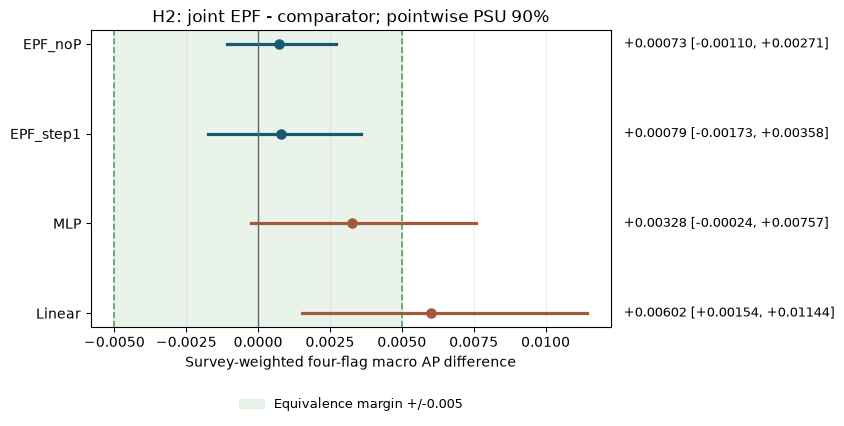

In [5]:
display(pd.DataFrame([{'contrast': name, **R['contrasts'][name]} for name in ('joint_EPF-joint_EPF_noP', 'joint_EPF-joint_EPF_step1', 'joint_EPF-joint_MLP', 'joint_EPF-joint_Linear')]))
rows = [R['contrasts'][name] for name in ('joint_EPF-joint_EPF_noP', 'joint_EPF-joint_EPF_step1', 'joint_EPF-joint_MLP', 'joint_EPF-joint_Linear')]
fig, ax = plt.subplots(figsize=(10, 4.7))
if 'h2_ci90' == 'h2_ci90':
    margin = R['prespecified_rules']['equivalence_margin']
    ax.axvspan(-margin, margin, color='#dcebdc', alpha=.6, label='Equivalence margin +/-0.005')
    ax.axvline(-margin, color='#579f67', ls='--', lw=1.2)
    ax.axvline(margin, color='#579f67', ls='--', lw=1.2)
for index, row in enumerate(rows):
    color = '#165a72' if row['supported'] else '#a25a3a'
    lo, hi = row['psu_ci90']
    ax.plot([lo, hi], [index, index], color=color, lw=2.3)
    ax.scatter(row['estimate'], index, color=color, s=43, zorder=3)
    ax.text(1.025, index, f"{row['estimate']:+.5f} [{lo:+.5f}, {hi:+.5f}]",
            transform=ax.get_yaxis_transform(), va='center', fontsize=9)
ax.axvline(0., color='#666666', lw=1)
ax.set_yticks(range(len(rows)), ('EPF_noP', 'EPF_step1', 'MLP', 'Linear')); ax.invert_yaxis()
ax.set_xlabel('Survey-weighted four-flag macro AP difference')
ax.set_title('H2: joint EPF - comparator; pointwise PSU 90%')
ax.grid(axis='x', alpha=.2)
if 'h2_ci90' == 'h2_ci90':
    ax.legend(loc='upper center', bbox_to_anchor=(.5, -.20), fontsize=9, frameon=False)
fig.subplots_adjust(left=.13, right=.65, bottom=.23, top=.86)
display(fig); plt.close(fig)

## 설계 효과 평균과 joint 구조 관측 범위

후자의 최대–최소는 기술 통계이며 구간 추정이나 인과 효과가 아니다.

In [6]:
display(pd.DataFrame([R['mean_design_effect']]))
display(pd.DataFrame([R['joint_structure_range']]))

,estimate,fold_diff,psu_ci90,psu_ci95
0,0.014877,"[0.021493342536505387, 0.024455082473612444, 0...","[0.007091178273206394, 0.022196977081932086]","[0.005533888387078335, 0.023614833683019185]"


,descriptive_only,interval,maximum_architectures,maximum_macro_ap,minimum_architectures,minimum_macro_ap,range
0,True,None,[EPF],0.381397,[Linear],0.375376,0.00602


## 50개 선택 설정, 평균 best epoch, 파라미터

평균은 선택된 5 seeds/설정 또는 25개 단위/칸이다. 전체 평균은 100개 단위/칸이며 DONE 메타데이터에서 집계했다. 중앙값과 epoch 1 개수는 선택된 25개 단위의 선택 시점 분포다. epoch 1 선택만으로 로지스틱 앵커에서 움직이지 않았거나 일반화할 수 없다고 판단하지 않는다.

In [7]:
chosen = [{'cell': name, **row} for name in CELLS for row in R['cells'][name]['chosen']]
assert len(chosen) == 50
display(pd.DataFrame(chosen))
display(pd.DataFrame([{'cell': name, **{key: R['cells'][name][key] for key in ('training_units','selected_units','selected_mean_best_epoch','selected_median_best_epoch','selected_best_epoch_one_count','mean_best_epoch_all_units','parameters','selected_parameters')}} for name in CELLS]))

,cell,config,fold,lr,selected_mean_best_epoch,selected_parameters,selected_seed_count,selection_score_kind,weight_decay
0,binary_Linear,0,1,0.0003,1.0,[460],5,BCE,0.000
1,binary_Linear,3,2,0.0010,2.2,[460],5,BCE,0.001
2,binary_Linear,2,3,0.0010,1.2,[460],5,BCE,0.000
3,binary_Linear,2,4,0.0010,2.4,[460],5,BCE,0.000
4,binary_Linear,2,5,0.0010,2.4,[460],5,BCE,0.000
5,binary_MLP,3,1,0.0010,8.0,[8212],5,BCE,0.001
6,binary_MLP,3,2,0.0010,1.0,[8212],5,BCE,0.001
7,binary_MLP,1,3,0.0003,13.8,[8212],5,BCE,0.001
8,binary_MLP,2,4,0.0010,4.2,[8212],5,BCE,0.000
9,binary_MLP,3,5,0.0010,11.4,[8212],5,BCE,0.001


,cell,training_units,selected_units,selected_mean_best_epoch,selected_median_best_epoch,selected_best_epoch_one_count,mean_best_epoch_all_units,parameters,selected_parameters
0,binary_Linear,100,25,1.84,1,15,1.84,[460],[460]
1,binary_MLP,100,25,7.68,7,5,11.18,[8212],[8212]
2,binary_EPF,100,25,3.20,1,17,3.75,[5895],[5895]
3,binary_EPF_noP,100,25,3.16,1,17,3.90,[5893],[5893]
4,binary_EPF_step1,100,25,7.16,8,9,11.98,[5895],[5895]
5,joint_Linear,100,25,53.52,59,0,99.46,[654],[654]
6,joint_MLP,100,25,14.88,15,0,29.34,[8708],[8708]
7,joint_EPF,100,25,8.60,9,0,16.00,[5971],[5971]
8,joint_EPF_noP,100,25,8.28,9,0,14.32,[5969],[5969]
9,joint_EPF_step1,100,25,15.68,14,0,33.22,[5971],[5971]


## 실패·재시도·실행 시간 및 해시 결속

In [8]:
display(pd.DataFrame([{'item': key, 'value': value} for key, value in R['execution'].items()]))
display(pd.DataFrame([{'item': key, 'value': value} for key, value in R['provenance'].items() if not isinstance(value, dict)]))
print(f"PSU valid/requested: {R['psu_valid_draws']}/{R['psu_requested_draws']}")

,item,value
0,automatic_retries,0
1,completed_training_queue_elapsed_seconds_sum,1335.397092
2,completed_units,1000
3,completed_units_at_recovery,[683]
4,evaluation_attempts,1
5,evaluation_completed_at,2026-09-26T07:54:22.428857+00:00
6,evaluation_seconds,231.521724
7,evaluation_started_at,2026-09-26T07:50:30.907146+00:00
8,failed_evaluation_attempts,0
9,failed_fold_invocations,0


,item,value
0,evaluation_done_sha256,6722d4f13580a60660feff397b2c1dd7490f361d8ce293...
1,harness_log_manifest_sha256,b441479697c1000c8f47e8c1c5b9ff8689a555973c9d0a...
2,renderer_outside_training_sources,True
3,report_sha256,c04afe08c4c8a15c6a1cc5d4ca692d60fc222b0d36f28e...
4,selection_freeze_sha256,b07201f2c6b01ee47e143c31d65a1a41af6fa11ecf55b6...
5,selection_sha256,fa9a6b3a5a26d555a5c2576d8492507cb4f179ec054855...
6,study_sha256,84b0cfad565bc6c66eac35c7fed3a6169698d9efa318d3...
7,training_freeze_sha256,e1e79fd86705900191493834a944d0ba03de8c589ed14b...
8,unit_metadata_count,1000


PSU valid/requested: 2000/2000


## 해석 범위

재사용한 2021–2024 코호트의 탐색적 비교다. 독립 확인 실험·임상 선별 성능 검증·생물학적 기전 입증이 아니다.

PSU 구간은 고정된 OOF 예측에 조건부인 pointwise percentile 구간이다. H1은 95%, H2는 90%이며 다중비교 보정·동시구간이 아니다. 재학습·설정 선택·코호트 재사용의 불확실성은 포함하지 않는다.

joint 대 binary는 연속값 감독 신호, 손실(NLL/BCE), 앵커(Ridge/logistic), 출력 헤드 구조를 함께 바꾼 설계 묶음의 비교다. 출력 표현 하나만의 분리된 인과 효과로 해석하지 않는다.

H2 충족은 이번 주지표 macro AP·사전 한계 ±0.005·대상 코호트와 학습 예산에 한정된다. 16상태 NLL·보정·계산시간 등 모든 성능의 동등성이나 일반적인 구조 무관성을 뜻하지 않는다. 효과가 정확히 0이라는 증거도 아니며, 미충족도 곧바로 차이가 존재한다는 검정 결과는 아니다.

EPF_noP는 P 업데이트를 끄고 z/trace 기반 capacity-control 읽기로 대체한다. EPF_step1은 반복을 한 단계로 줄이며 초기 trace가 0이어서 최종 P도 0이다. 따라서 각각 순수한 P 제거 효과·반복 횟수만의 효과로 단정하지 않는다.

joint_Linear의 Linear는 평균 경로를 가리킨다. 입력 의존 공분산 경로와 flag 확률 변환은 비선형이므로 모델 전체가 선형인 비교가 아니다.

각 칸의 p4와 p16은 선택된 seed 42–46의 혼합이다. binary p16은 각 seed 안에서 네 Bernoulli의 독립곱을 만든 뒤 평균한다. 평균 주변확률의 독립곱과 일반적으로 다르며 seed 혼합은 의존성을 만들 수 있다.

16상태 categorical NLL은 각 칸이 만든 seed 혼합 공동예측 전체의 proper score다. 주변확률의 정확도와 보정도 영향을 주므로 NLL 차이를 의존성 모델링만의 효과로 분리해 해석하지 않는다. binary BCE와 joint 연속 Gaussian NLL은 서로 다른 학습·선택 점수이므로 수치 크기를 직접 비교하지 않는다.

fold와 seed는 독립 사람이나 독립 확인 실험의 수가 아니다. 구조 간 AP 범위는 관측한 다섯 joint 칸의 최대–최소이며 동등성 구간이나 인과 효과 범위가 아니다.

파라미터 수는 DONE 메타데이터의 requires_grad 파라미터 수다. 비영 gradient, 실제 업데이트, 유효 용량의 동등성을 검증한 수가 아니다.